In [1]:
#dataset = https://www.kaggle.com/datasets/shlokshivkar/classifieddata?select=Classified+Data+2.csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [2]:
df = pd.read_csv('KNN_Project_Data')

In [5]:
df.head()

,XVPM,GWYH,TRAT,TLLZ,IGGA,HYKR,EDFS,GUUB,MGJM,JHZC,TARGET CLASS
0,1636.670614,817.988525,2565.995189,358.347163,550.417491,1618.870897,2147.641254,330.727893,1494.878631,845.136088,0
1,1013.402760,577.587332,2644.141273,280.428203,1161.873391,2084.107872,853.404981,447.157619,1193.032521,861.081809,1
2,1300.035501,820.518697,2025.854469,525.562292,922.206261,2552.355407,818.676686,845.491492,1968.367513,1647.186291,1
3,1059.347542,1066.866418,612.000041,480.827789,419.467495,685.666983,852.867810,341.664784,1154.391368,1450.935357,0
4,1018.340526,1313.679056,950.622661,724.742174,843.065903,1370.554164,905.469453,658.118202,539.459350,1899.850792,0


In [7]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df.drop(columns = ['TARGET CLASS']))
df_features = pd.DataFrame(scaled_features, columns = df.drop(columns = ['TARGET CLASS']).columns)

In [9]:
x = df_features
y = df['TARGET CLASS']

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

In [19]:
model = KNeighborsClassifier(n_neighbors = 21)

In [20]:
model.fit(x_train, y_train)

,n_neighbors,21
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [21]:
predictions = model.predict(x_test)

In [22]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       146
           1       0.86      0.83      0.84       154

    accuracy                           0.84       300
   macro avg       0.84      0.84      0.84       300
weighted avg       0.84      0.84      0.84       300



<Axes: >

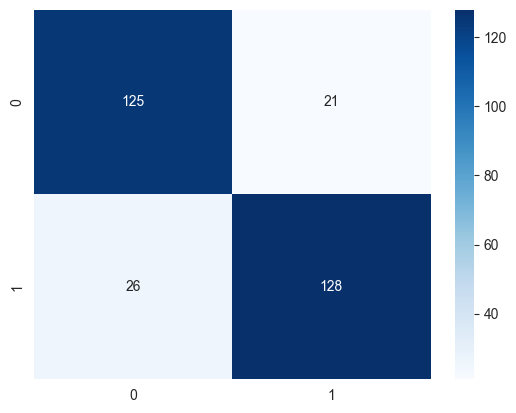

In [23]:
sns.heatmap(confusion_matrix(y_test, predictions), fmt = 'd', cmap = 'Blues', annot = True)

In [17]:
error_rate = []
for i in range(1, 40):
    model2 = KNeighborsClassifier(n_neighbors = i)
    model2.fit(x_train, y_train)
    predictions2 = model2.predict(x_test)
    error_rate.append(np.mean(predictions2 != y_test))

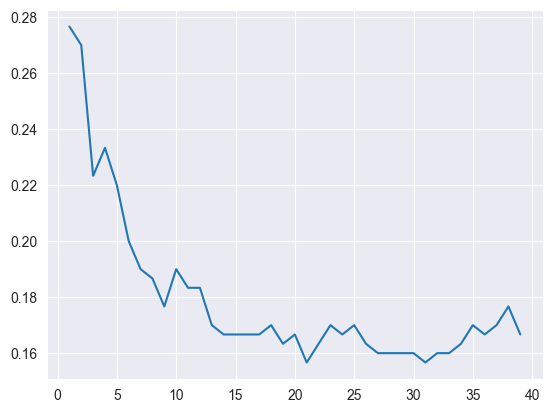

In [18]:
plt.plot(range(1, 40), error_rate)